# Visualisation des données Drug Discovery
Ce notebook permet de visualiser en 3D les complexes protéine-ligand et leur représentation en graphe.

In [1]:
import os
import py3Dmol
import networkx as nx
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd

# Chemins des données
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
REFINED_SET = os.path.join(DATA_DIR, "PDBbind_v2020_refined", "refined-set")
TRAIN_CSV = os.path.join(DATA_DIR, "train_data.csv")

## 1. Visualisation 3D (Protéine + Médicament)

In [3]:
def visualize_3d(pdb_id):
    pdb_path = os.path.join(REFINED_SET, pdb_id, f"{pdb_id}_protein.pdb")
    sdf_path = os.path.join(REFINED_SET, pdb_id, f"{pdb_id}_ligand.sdf")
    
    view = py3Dmol.view(width=800, height=600)
    
    # Charger la protéine
    with open(pdb_path, 'r') as f:
        view.addModel(f.read(), 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    
    # Charger le ligand
    with open(sdf_path, 'r') as f:
        view.addModel(f.read(), 'sdf')
    view.setStyle({'model': -1}, {'stick': {'colorscheme': 'greenCarbon'}})
    
    view.zoomTo()
    return view.show()

# Exemple avec un ID du dataset
df = pd.read_csv(TRAIN_CSV)
sample_id = df.iloc[0]['pdb_id']
print(f"Affichage du complexe : {sample_id}")
visualize_3d(sample_id)

Affichage du complexe : 2r58


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 2. Visualisation du Graphe Moléculaire
Voici ce que l'IA "voit" réellement (les connexions entre atomes).

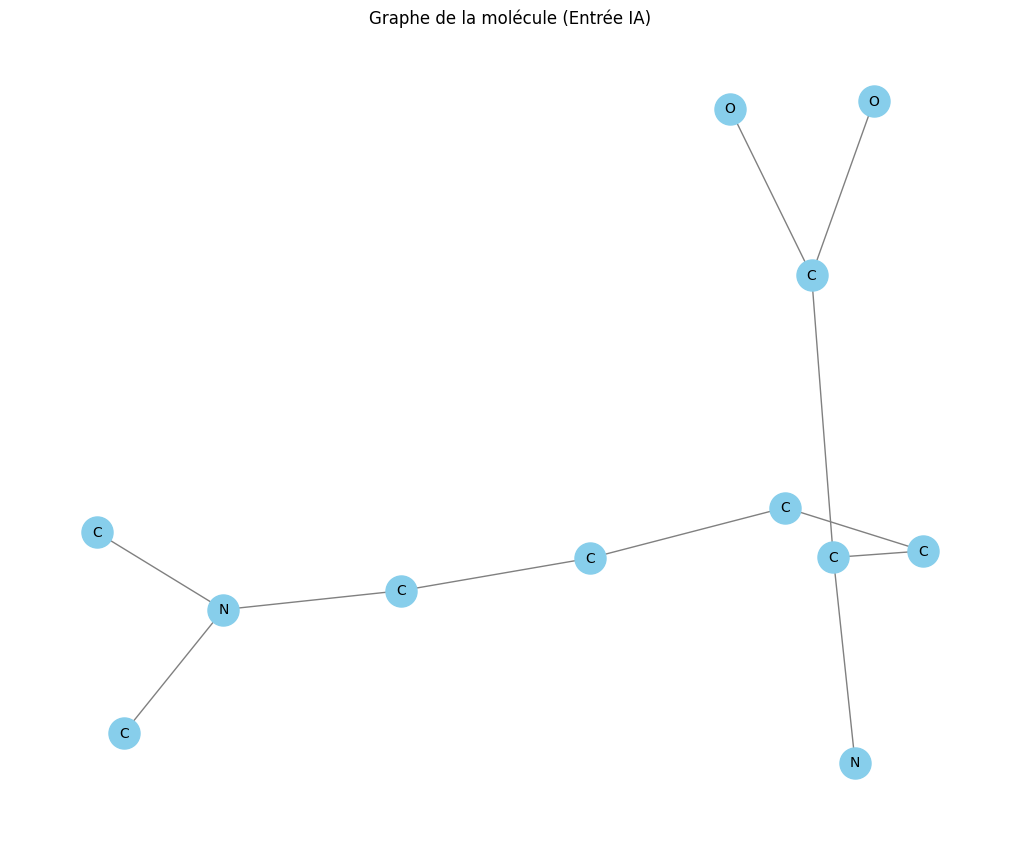

In [4]:
def visualize_molecule_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    G = nx.Graph()
    
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), symbol=atom.GetSymbol())
        
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
        
    plt.figure(figsize=(10, 8))
    labels = nx.get_node_attributes(G, 'symbol')
    pos = nx.spring_layout(G)
    nx.draw(G, pos, labels=labels, with_labels=True, node_color='skyblue', 
            node_size=500, edge_color='gray', font_size=10)
    plt.title("Graphe de la molécule (Entrée IA)")
    plt.show()

sample_smiles = df.iloc[0]['smiles']
visualize_molecule_graph(sample_smiles)